<a href="https://colab.research.google.com/github/AslamF/DATA602-FinalProject-/blob/main/DATA602FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Health & Lifestyle Analysis
### DATA 602 Final Project | Fraz Aslam

## Abstract

This project investigates the relationship between sleep health and lifestyle factors
using the Sleep Health and Lifestyle Dataset sourced from Kaggle. The dataset contains
373 records across 13 variables including occupation, gender, age, sleep duration,
quality of sleep, physical activity level, stress level, BMI category, blood pressure,
heart rate, daily steps, and sleep disorder diagnosis. The central research questions
explore which occupations are associated with the poorest sleep quality and duration,
whether physical activity levels correlate with better sleep outcomes, and whether gender
differences exist in average sleep duration. Exploratory data analysis reveals notable
variation in sleep quality across professions and a positive relationship between physical
activity and sleep quality. Findings from this analysis can be useful for understanding
how lifestyle and occupational factors influence sleep health.

## Introduction

Sleep is one of the most critical components of overall health, yet it is frequently
overlooked in discussions about wellness. Poor sleep quality and insufficient sleep
duration have been linked to a range of negative health outcomes including increased
stress, reduced cognitive function, and higher risk of chronic illness.

This project seeks to answer the following research questions:

1. Which occupation has the worst sleep quality and/or sleep duration?
2. Is there a relationship between physical activity level and sleep quality or duration?
3. Do males or females get more sleep on average?

The dataset used is the Sleep Health and Lifestyle Dataset from Kaggle, which contains
373 observations across 13 variables capturing demographic, occupational, and health
related information. Data has been uploaded to github to be reproduced freely.

In [8]:
# --- Imports & Load Data ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/AslamF/DATA602-FinalProject-/refs/heads/main/sleep.csv"
df=pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.dtypes)

(374, 13)
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80        

## Data Wrangling

Before analysis, the dataset required the following cleaning steps:

- The Sleep Disorder column contained the string value 'None' rather than a true null.
  This was standardized to 'No Disorder' for clarity.
- The Blood Pressure column was stored as a single string in the format "120/80".
  This was split into two separate numeric columns: BP Systolic and BP Diastolic.
- The Person ID column was dropped as it carries no analytical value.
- No true missing values were found across the remaining columns.

In [9]:
# --- Data Wrangling ---

# Check missing values
print(df.isnull().sum())

# Standardize Sleep Disorder column
df['Sleep Disorder'] = df['Sleep Disorder'].replace('None', 'No Disorder')
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

# Split Blood Pressure into two numeric columns
df[['BP Systolic', 'BP Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# Drop columns not needed for analysis
df = df.drop(columns=['Blood Pressure', 'Person ID'])

print(df.dtypes)
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
BP Systolic                  int64
BP Diastolic                 int64
dtype: object
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0

## Exploratory Data Analysis

The following visualizations directly address each research question.

**Plot 1** shows the average sleep quality score for each occupation, identifying which
professions are associated with the poorest and best sleep quality.

**Plot 2** shows the average sleep duration in hours by occupation, highlighting whether
low quality also corresponds to less total sleep.

**Plot 3** shows average sleep quality grouped by physical activity level, illustrating
whether more active individuals report better sleep quality.

**Plot 4** shows the distribution of sleep duration for males and females, making it easy
to compare medians and spread between the two groups.

              Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
count  374.000000      374.000000        374.000000               374.000000   
mean    42.184492        7.132086          7.312834                59.171123   
std      8.673133        0.795657          1.196956                20.830804   
min     27.000000        5.800000          4.000000                30.000000   
25%     35.250000        6.400000          6.000000                45.000000   
50%     43.000000        7.200000          7.000000                60.000000   
75%     50.000000        7.800000          8.000000                75.000000   
max     59.000000        8.500000          9.000000                90.000000   

       Stress Level  Heart Rate   Daily Steps  BP Systolic  BP Diastolic  
count    374.000000  374.000000    374.000000   374.000000    374.000000  
mean       5.385027   70.165775   6816.844920   128.553476     84.649733  
std        1.774526    4.135676   1617.915679     7.74

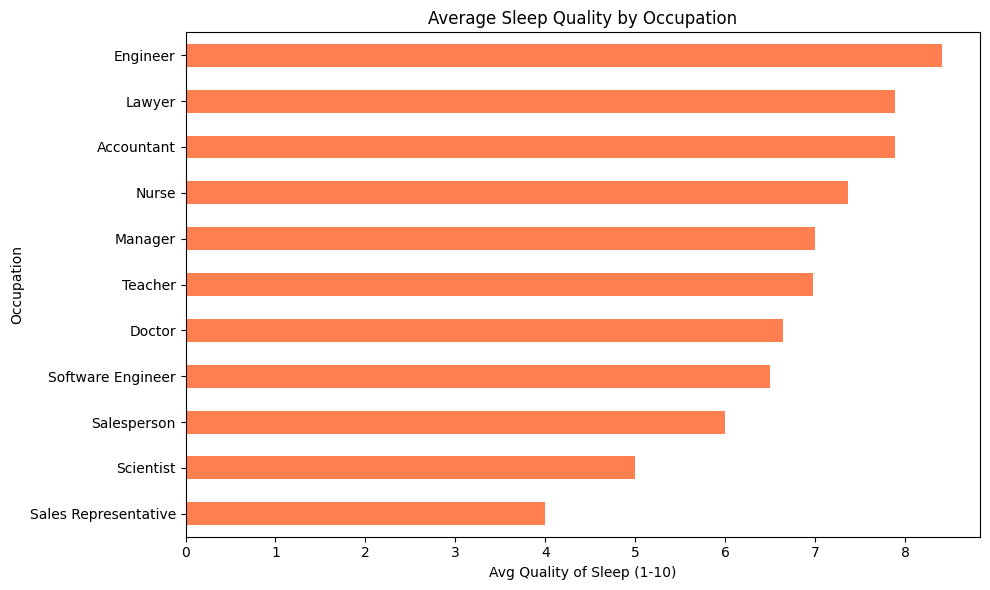

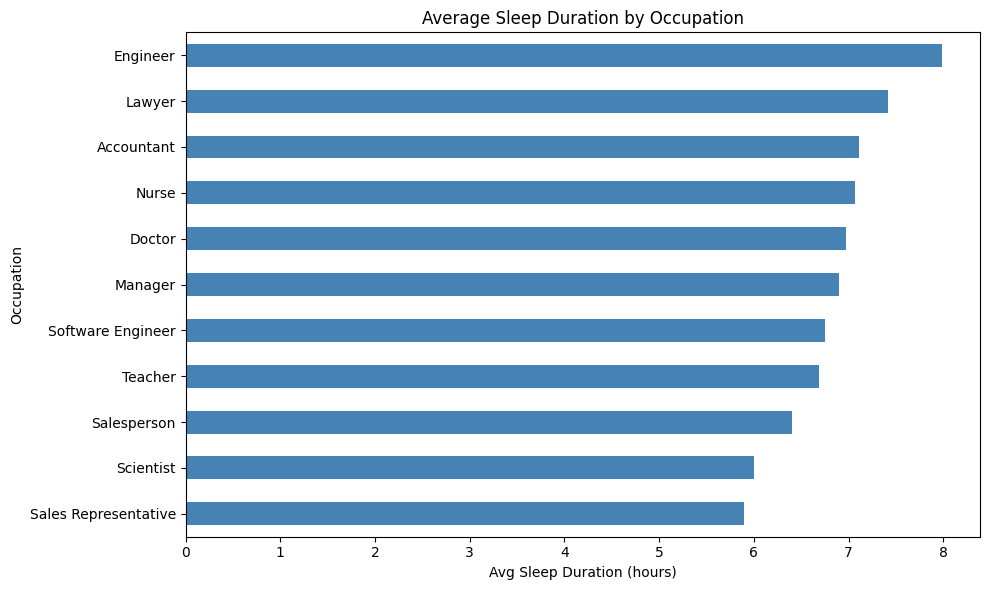

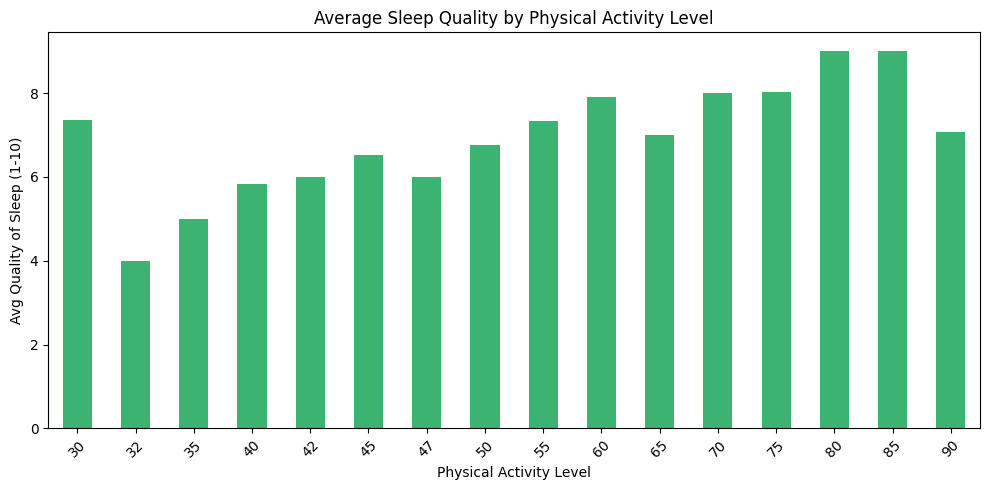

/tmp/ipykernel_19518/1371143355.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Sleep Duration', palette='Set2')


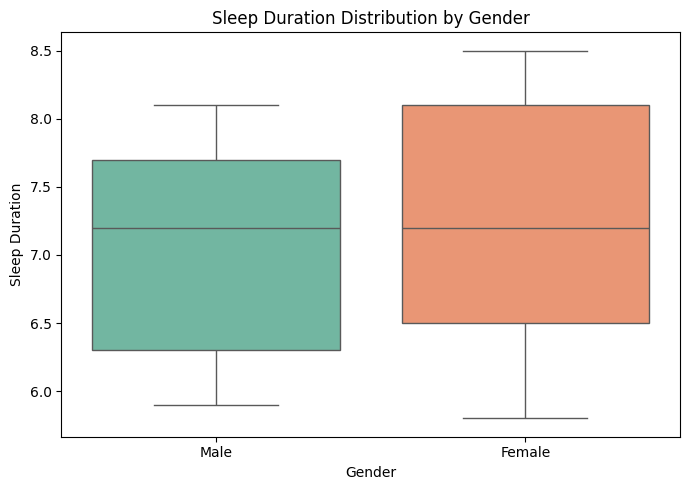

In [10]:
# --- EDA & Visualizations ---

print(df.describe())

# Plot 1: Average Sleep Quality by Occupation
occ_quality = df.groupby('Occupation')['Quality of Sleep'].mean().sort_values()

plt.figure(figsize=(10, 6))
occ_quality.plot(kind='barh', color='coral')
plt.title('Average Sleep Quality by Occupation')
plt.xlabel('Avg Quality of Sleep (1-10)')
plt.tight_layout()
plt.show()

# Plot 2: Average Sleep Duration by Occupation
occ_sleep = df.groupby('Occupation')['Sleep Duration'].mean().sort_values()

plt.figure(figsize=(10, 6))
occ_sleep.plot(kind='barh', color='steelblue')
plt.title('Average Sleep Duration by Occupation')
plt.xlabel('Avg Sleep Duration (hours)')
plt.tight_layout()
plt.show()

# Plot 3: Average Sleep Quality by Physical Activity Level
act_quality = df.groupby('Physical Activity Level')['Quality of Sleep'].mean()

plt.figure(figsize=(10, 5))
act_quality.plot(kind='bar', color='mediumseagreen')
plt.title('Average Sleep Quality by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Avg Quality of Sleep (1-10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: Sleep Duration by Gender
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Gender', y='Sleep Duration', palette='Set2')
plt.title('Sleep Duration Distribution by Gender')
plt.tight_layout()
plt.show()

## Data Analysis

With the visualizations providing an initial picture, the analysis section quantifies
the relationships observed. Grouped means by occupation and gender are calculated to
directly answer the research questions, and Pearson correlation coefficients are computed
to measure the strength of the relationship between physical activity and sleep outcomes.

In [11]:
# --- Data Analysis ---

# Sleep Duration & Quality by Occupation
print("Sleep Duration & Quality by Occupation:")
print(df.groupby('Occupation')[['Sleep Duration', 'Quality of Sleep']].mean().round(2).sort_values('Quality of Sleep'))

# Average Sleep by Gender
print("\nAverage Sleep Duration by Gender:")
print(df.groupby('Gender')['Sleep Duration'].mean().round(2))

print("\nAverage Sleep Quality by Gender:")
print(df.groupby('Gender')['Quality of Sleep'].mean().round(2))

# Physical Activity Correlations
corr_quality = df['Physical Activity Level'].corr(df['Quality of Sleep'])
corr_duration = df['Physical Activity Level'].corr(df['Sleep Duration'])

print(f"\nCorrelation — Physical Activity & Sleep Quality: {corr_quality:.3f}")
print(f"Correlation — Physical Activity & Sleep Duration: {corr_duration:.3f}")

Sleep Duration & Quality by Occupation:
                      Sleep Duration  Quality of Sleep
Occupation                                            
Sales Representative            5.90              4.00
Scientist                       6.00              5.00
Salesperson                     6.40              6.00
Software Engineer               6.75              6.50
Doctor                          6.97              6.65
Teacher                         6.69              6.98
Manager                         6.90              7.00
Nurse                           7.06              7.37
Accountant                      7.11              7.89
Lawyer                          7.41              7.89
Engineer                        7.99              8.41

Average Sleep Duration by Gender:
Gender
Female    7.23
Male      7.04
Name: Sleep Duration, dtype: float64

Average Sleep Quality by Gender:
Gender
Female    7.66
Male      6.97
Name: Quality of Sleep, dtype: float64

Correlation — Physical Ac

## Conclusions

The analysis of the Sleep Health and Lifestyle Dataset produced the following key findings:

**Occupation & Sleep:**
Sales Representatives had the worst sleep quality and duration in the dataset, averaging
only 5.9 hours of sleep per night with a quality score of 4.0 out of 10. Scientists were
second worst at 6.0 hours and a quality score of 5.0. On the opposite end, Engineers
reported the best outcomes with an average of 7.99 hours and a quality score of 8.41.
This suggests that customer-facing roles with more daily interaction are associated with significantly
worse sleep health compared to technical and analytical professions where there is potentially less customer/client interaction.

**Physical Activity & Sleep:**
The correlation between physical activity and sleep quality was 0.193, and between
physical activity and sleep duration was 0.212. Both correlations are positive, confirming
that more active individuals tend to sleep better and longer. However, the relationship is
weak, meaning physical activity alone is not a strong predictor of sleep outcomes. Other
factors such as occupation and stress level likely have a greater influence.

**Gender & Sleep:**
Females averaged 7.23 hours of sleep per night compared to 7.04 hours for males, and
reported higher sleep quality scores of 7.66 versus 6.97. While females outperform males
on both measures, the differences are not significant enough to make any statements.

**Overall:**
This analysis highlights that occupation is the strongest differentiator of sleep health
in this dataset, with lifestyle factors like physical activity playing a secondary role. Future work could incorporate variables such as diet, screen time,
or work hours to build a more complete picture of what drives sleep quality.

In [12]:
# --- Conclusions ---

worst_quality = df.groupby('Occupation')['Quality of Sleep'].mean().idxmin()
best_quality = df.groupby('Occupation')['Quality of Sleep'].mean().idxmax()
least_sleep = df.groupby('Occupation')['Sleep Duration'].mean().idxmin()
most_sleep = df.groupby('Occupation')['Sleep Duration'].mean().idxmax()
gender_sleep = df.groupby('Gender')['Sleep Duration'].mean()

print("=== KEY FINDINGS ===\n")
print(f"Worst sleep quality occupation:  {worst_quality}")
print(f"Best sleep quality occupation:   {best_quality}")
print(f"Least sleep duration occupation: {least_sleep}")
print(f"Most sleep duration occupation:  {most_sleep}")
print(f"\nAvg sleep duration - Male: {gender_sleep['Male']:.2f} hrs | Female: {gender_sleep['Female']:.2f} hrs")
print(f"\nPhysical Activity vs Sleep Quality correlation: {corr_quality:.3f}")
print(f"Physical Activity vs Sleep Duration correlation: {corr_duration:.3f}")

=== KEY FINDINGS ===

Worst sleep quality occupation:  Sales Representative
Best sleep quality occupation:   Engineer
Least sleep duration occupation: Sales Representative
Most sleep duration occupation:  Engineer

Avg sleep duration - Male: 7.04 hrs | Female: 7.23 hrs

Physical Activity vs Sleep Quality correlation: 0.193
Physical Activity vs Sleep Duration correlation: 0.212
